# Email Spam Detection using Machine Learning

## Objective
To build a machine learning model that detects whether an email is spam or non-spam.

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn

## Machine Learning Model
Multinomial Naive Bayes

In [29]:
import pandas as pd
import numpy as np

In [30]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [31]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [33]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')


In [34]:
df = df[['v1', 'v2']]

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [35]:
df.columns = ['Category', 'Message']

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [36]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [37]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
X = df['Message']

y = df['Category']

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

In [40]:
cv = CountVectorizer()

X = cv.fit_transform(X)

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.naive_bayes import MultinomialNB

In [44]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3860., 597.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.01]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 8672)","[[ 0., 0., 1.,..., 0., 9., 1.], [ 8.,23., 0.,..., 1., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 8672)","[[-10.98,-10.98,-10.28,...,-10.98, -8.67,-10.28], [ -7.83, -6.85,-10.03,..., -9.34,-10.03,-10.03]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8672


In [45]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 1 0 1 0 0 0 0 0]


In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97847533632287


In [48]:
from sklearn.metrics import classification_report

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [50]:
sample = ["Congratulations! You won a free iPhone. Click now to claim your prize"]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

print(prediction)

[1]


In [51]:
sample = ["Hey, are we meeting for lunch today?"]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

print(prediction)

[0]


In [52]:
from sklearn.metrics import confusion_matrix

In [53]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[952  13]
 [ 11 139]]


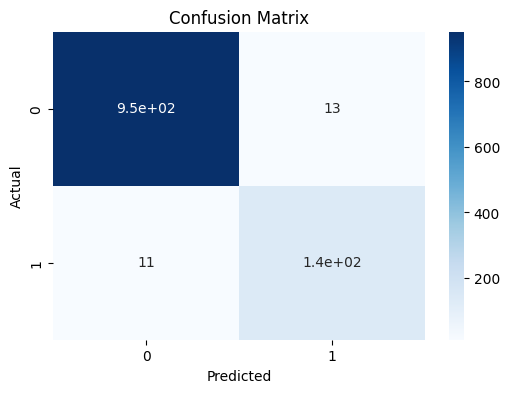

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [55]:
sample = ["Congratulations! You won a free iPhone. Click now to claim your prize"]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email


In [56]:
sample = ["Hey, are we meeting for lunch today?"]

sample_data = cv.transform(sample)

prediction = model.predict(sample_data)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Not Spam


# Conclusion

A machine learning model was developed to detect spam emails using the Multinomial Naive Bayes algorithm. Email text data was converted into numerical format using CountVectorizer, and the model was trained to classify emails as spam or non-spam. The model achieved an accuracy of approximately 97.85%, showing excellent performance in identifying spam messages.